In [1]:
print("Importing numpy")
import numpy as np
print("Importing math")
import math
print("Importing tqdm")
from tqdm import tqdm

xy=np.array ([[6,6]])#start coordinate
d=4#dimension
working =[]
test =[]
test1=[]
print("Starting loop")
for n in tqdm(range(1296,15,-1)):#range of n values
    for p in range(2,int(n/2+1)):
        for q in range(p+1,int(n/2+1)):
            for r in range(q+1,int(n/2+1)):
                test.append ([p,q,r]) #set of all possibilities
    for k in range(math.floor(n/xy[-1][0]+1),4000):
        for q in test:
            f=0
            for i in range(1,k):
                working =[(i*q[0])%n,(i*q[1])%n,(i*q[2])%n]
                #working needs to be changed for more q’s
                true=0
                for a in working:
                    if a>=k and n-k>=a:
                        true=1
                if true==0:
                    f=1
                    break
            if f==0:
                k1=k
                n1=n
                test1.append(q)
        if test1==[]:
            if k>math.floor(n/xy[-1][0]+1):
                xy=np.append(xy ,[[n1/k1,n1**(1/d)]],axis=0)
            break
        test=list(test1)
        test1=[]
    test =[]
xy=np.flip(xy ,0)

#Plotting the results in a step plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.step(xy[:, 0], xy[:, 1], where='post')
plt.xlabel('n/k')
plt.ylabel('n^(1/d)')
plt.title('Step Plot of n/k vs n^(1/d)')
plt.grid()
plt.show()

Importing numpy
Importing math
Importing tqdm
Starting loop


  0%|          | 0/1281 [00:22<?, ?it/s]


KeyboardInterrupt: 

In [2]:
import networkx as nx

def neighbours(n,k): # gives neighbours for vertex of dimension 1
    tot =[]
    for i in range(n):
        neigh =[]
        for i in range(i-k+1,i+k):
            neigh.append(i%n)
        tot.append(neigh)
    return tot

def network(vertices ,edges): #makes the graph
    G = nx.Graph()
    for i in range(len(vertices )):
        a=0
        for j in range(len(vertices[i])):
            a+= vertices[i][j]*10**j
        G.add_node(a)
    for i in range(len(vertices )):
        a=0
        for j in range(len(vertices[i])):
            a+= vertices[i][j]*10**j
        for j in range(len(edges[i])):
            b=0
            for k in range(len(edges[i][j])):
                b+=edges[i][j][k]*10**k
            G.add_edge(a, b)
        return G
    
def full(n,d):#gives all vertices
    tot =[]
    for a in range(n**d):
        b=[]
        for i in range(d):
            b.append(a//(n**i)%n)
        tot.append(b)
    return tot

def edges(n,tot):#gives all edges of vertices
    edg =[]
    for a in tot:
        edg1=[]
        for b in tot:
            true=0
            for i in range(len(a)):
                if b[i] not in n[a[i]]:
                    true=1
            if true==0 and a not in edg1 and a!=b:
                edg1.append(b)
        edg.append(edg1)
    return edg

def deep(G,b,se ,final ,k,d):#exhaustive searching
    if len(list(G.nodes ))==0:
        if len(se)>=len(final):
            final=list(se)
        return(final)
    for a in G.nodes:
        if a<=b:
            nodes=list(G.neighbors(a))
            d=0
            for i in nodes:
                if i>=b:
                    break
                d+=1
            if nx.density(G.subgraph(nodes[d:]))==1:
                break
        if a>b:
            se.append(a)
            G1=nx.Graph(G)
            e=list(G.neighbors(a))
            e.append(a)
            G1.remove_nodes_from(e)
            final=deep(G1,a,se,final,k,d)
            se.pop()
    return(final)

n=10# set for C(n,k)^d
d=2
k=3
tot=full(n,d)
neigh=neighbours(n,k)
edg=edges(neigh ,tot)
G=network(tot ,edg)
e=[0]
for i in G.neighbors(0):
    e.append(i)

G.remove_nodes_from(e)
final=deep(G,0 ,[0],[],k,d) # set counting largest independent set

KeyboardInterrupt: 

In [ ]:
for r in range(3,10):
    print("r = ",r)
    for n in range(0,5):
        print("n = ",n, "Qn = ", (1+(r**n)*(r-2))/(r-1))

r =  3
n =  0 Qn =  1.0
n =  1 Qn =  2.0
n =  2 Qn =  5.0
n =  3 Qn =  14.0
n =  4 Qn =  41.0
r =  4
n =  0 Qn =  1.0
n =  1 Qn =  3.0
n =  2 Qn =  11.0
n =  3 Qn =  43.0
n =  4 Qn =  171.0
r =  5
n =  0 Qn =  1.0
n =  1 Qn =  4.0
n =  2 Qn =  19.0
n =  3 Qn =  94.0
n =  4 Qn =  469.0
r =  6
n =  0 Qn =  1.0
n =  1 Qn =  5.0
n =  2 Qn =  29.0
n =  3 Qn =  173.0
n =  4 Qn =  1037.0
r =  7
n =  0 Qn =  1.0
n =  1 Qn =  6.0
n =  2 Qn =  41.0
n =  3 Qn =  286.0
n =  4 Qn =  2001.0
r =  8
n =  0 Qn =  1.0
n =  1 Qn =  7.0
n =  2 Qn =  55.0
n =  3 Qn =  439.0
n =  4 Qn =  3511.0
r =  9
n =  0 Qn =  1.0
n =  1 Qn =  8.0
n =  2 Qn =  71.0
n =  3 Qn =  638.0
n =  4 Qn =  5741.0


In [6]:
import cvxpy as cvx
import numpy as np
# import matplotlib.pyplot as plt
# import networkx as nx
import math
from tqdm import tqdm

def cycle_adjacency(n):
    G = np.zeros((n, n), dtype=int)
    for i in range(n):
        G[i, (i + 1) % n] = 1
        G[(i + 1) % n, i] = 1
    return G

def solve_theta(G):
    n = G.shape[0]
    X = cvx.Variable((n, n), symmetric=True)

    constraints = [X >> 0]  # X is positive semidefinite
    constraints.append(cvx.trace(X) == 1)  # Diagonal entries are 1
    for i in range(n):
        for j in range(n):
            if G[i, j] == 1 and i != j:
                constraints.append(X[i, j] == 0)  # Non-edges have zero entries

    objective = cvx.Maximize(cvx.sum(X))
    problem = cvx.Problem(objective, constraints)
    problem.solve()

    return problem.value

#Calculates upper bound at n,d using theta function of cycle graph
def upper_bound(n, d):
    G = cycle_adjacency(n)
    theta_value = solve_theta(G)
    return math.floor(theta_value ** d)

def check_S(n, d):
    k_max = 0
    q_max = []
    for q in range(2, n // 2 + 1):
        q_array = np.array([q**i for i in range(d)])
        # Vectorized: multiply q_array by all t values at once
        t_array = q_array * np.arange(1, n)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array = np.minimum(t_array, n - t_array)
        # Vectorized min of max: find max along each row, then min across rows
        k_plus = t_array.max(axis=1).min()
        if k_plus > k_max:
            k_max = k_plus
            q_max = [q]
        elif k_plus == k_max:
            q_max.append(q)
    return k_max, q_max


from fractions import Fraction
def check_S_fractional(n,d):
    
    k_max = 0
    q_max = []
    
    # # Generate all q values: integers and fractions with denominators 3, 4, 5
    # q_values = set()
    
    # # Add integers
    # for q in range(2, n // 2 + 1):
    #     q_values.add(Fraction(q))
    
    # # Add fractions with denominators 3, 4, 5
    # for denom in [7, 8, 9, 10,11,12,13]:
    #     min_num = 2 * denom
    #     max_num = denom * (n // 2 + 1)
    #     for num in range(min_num, int(max_num) + 1):
    #         q_val = Fraction(num, denom)
    #         q_values.add(q_val)
    
    # # Sort by value
    # q_values = sorted(list(q_values))
    # q_values = []
    q_values = np.linspace(2, int(np.ceil(n))//2, num=500*(int(np.ceil(n))//2-2)+1)

    # for denom in range(3, 6):
    #     for num in range(2*denom, int(denom*(n//2+1))+1):
    #         q_values.append(num/denom)
    # q_values = [39.0000000000001,39,38.9999999999999]
    multi = 1
    for q in q_values:
        q_array = np.array([float(q**i) for i in range(d)])
        # Vectorized: multiply q_array by all t values at once
        t_array = q_array * np.arange(1, n)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array_f = np.minimum(t_array, n - t_array)
        # Vectorized min of max: find max along each row, then min across rows
        k_plus = t_array_f.max(axis=1).min()
        if k_plus > k_max:
            k_max = k_plus
            q_max = [q]
            k_1 = t_array.max(axis=1).min()
            k_2 = (n-t_array).max(axis=1).min()
            if (k_1 == k_2):
                multi = 2
            else:
                multi = 1
        elif k_plus == k_max:
            q_max.append(q)
            k_1 = t_array.max(axis=1).min()
            k_2 = (n-t_array).max(axis=1).min()
            if (k_1 == k_2):
                multi = 2
    return k_max, q_max, multi

from itertools import combinations

def generate_coprime_q_arrays(n, d):
    max_q = n // 2
    results = []

    def backtrack(combo, start):
        if len(combo) == d - 1:
            results.append([1] + list(combo))
            return
        for q in range(start, max_q + 1):
            if all(math.gcd(q, c) == 1 for c in combo):
                combo.append(q)
                backtrack(combo, q + 1)
                combo.pop()

    backtrack([], 2)
    return np.array(results)

def generate_q_arrays(n, d):
    max_q = n // 2
    q_arrays = np.array([np.array([1] + list(combo)) for combo in combinations(range(2, max_q + 1), d - 1)])
    return q_arrays

def check_T(n, d):
    k_max = 0
    q_max = []
    multi = 1
    q_arrays = generate_coprime_q_arrays(n, d)
    print(f"Number of q arrays to check: {len(q_arrays)}")
    for q_array in q_arrays:
        # Vectorized array creation
        t_array = q_array * np.arange(1, n)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array = np.minimum(t_array, n - t_array)
        # Vectorized min of max
        k_plus = t_array.max(axis=1).min()
        if k_plus > k_max:
            k_max = k_plus
            q_max = q_array
            
    return k_max, q_max

def check_U(n, d):
    k_max = 0
    q_max = []

    # Build all (a, b) with a, b >= 0 and a + b = s for s in 1..n.
    # Each row in coeffs is one coefficient pair [a, b].
    # coeffs = np.array(
    #     [[a, s - a] for s in range(1, n) for a in range(s + 1)],
    #     dtype=np.int64,
    # )
    # Get all pairs (a,b) with a or b 0
    coeffs = np.array(
        [[a, 0] for a in range(1,n)] + [[0, b] for b in range(1,n)],
        dtype=np.int64,
    )
    # coeffs = np.array(
    #     [[a, 0] for a in range(1,n)],
    #     dtype=np.int64,
    # )
    # coeffs = np.delete(coeffs, np.where((coeffs[:, 0] == 0) & (coeffs[:, 1] == 0)), axis = 0)
    for q in tqdm(combinations(range(2, n // 2 + 1), 2)):
        if (math.gcd(q[0],q[1])==1):
            q_array = np.zeros((2, d), dtype=np.int64)
            for j in range(2):
                q_array[j] = np.array([q[j] ** i for i in range(d)], dtype=np.int64)

            # Linear combination for each coefficient pair:
            # t = a*q_array[0] + b*q_array[1]
            t_array = coeffs @ q_array
            t_array = np.mod(t_array, n)
            t_array = np.minimum(t_array, n - t_array)

            # For each (a,b) row, take max over dimensions; then min across rows.
            k_plus = t_array.max(axis=1).min()
            if k_plus > k_max:
                k_max = k_plus
                q_max = [q]
            elif k_plus == k_max:
                q_max.append(q)

    return k_max, q_max

def find_solution(p, dimensions, lower_bounds, SorT):
    for i in range(len(dimensions)):
        min_ratio = p
        d = dimensions[i]
        l_bound = lower_bounds[i]
        # if (d == 7):
        #     u_bound = 3438
        # elif (d == 8):
        #     u_bound = 10314
        # elif (d == 9):
        #     u_bound = 30942
        # elif (d == 4):
        #     u_bound = 383
        # else:
        #     u_bound = upper_bound(p, d)
        u_bound = upper_bound(p, d)
        print(f"Dimension: {d}, Lower Bound: {l_bound}, Upper Bound: {u_bound}")
        # n_range = np.linspace(l_bound, u_bound, num=(u_bound-l_bound)+1)
        # print(n_range)
        for n in range(l_bound, u_bound+1):
            if (SorT == 'S'):
                max_k, q_max = check_S(n, d)
            elif (SorT == 'U'):
                max_k, q_max = check_U(n, d)
            elif (SorT == 'S_fractional'):
                max_k, q_max, multi = check_S_fractional(n, d)
            else:
                max_k, q_max = check_T(n, d)
            if max_k is not None and max_k > n/np.ceil(p/2):
                # print(f"Found solution for n={n}, d={d}: max_k={max_k}, n/k={n/max_k}, q_max={q_max}, multi={multi}")
                print(f"Found solution for n={n}, d={d}: max_k={max_k}, n/k={n/max_k}, q_max={q_max}")
                min_ratio = min(min_ratio, n/max_k)
        print(f"Best ratio found for this dimension was {min_ratio}")

        #Here check values larger than the upper bound        

p = 7
dimensions = [3, 4, 5, 6, 7, 8]
lower_bounds = [33, 108, 350, 1101, 3438, 10314, 30942, 92826]
#lower_bounds = [30712,965097,30220701,943226944]
# dimensions = [5, 6, 7, 8]
# lower_bounds = [183, 1101, 3438, 10314]
#lower_bounds = [18,81, 324, 1458, 6561]
choice = 'S'  # or 'T' depending on which one you want to check
find_solution(p, dimensions, lower_bounds, choice)  
# q = 273
# d = 11
# n = 1146*3**5  # Example value for n
# q_array = np.array([q**i for i in range(d)])
# # Vectorized: multiply q_array by all t values at once
# t_array = q_array * np.arange(1, n)[:, np.newaxis]
# t_array = np.mod(t_array, n)
# t_array = np.minimum(t_array, n - t_array)
# # Vectorized min of max: find max along each row, then min across rows
# k_plus = t_array.max(axis=1).min() 
# print(k_plus)
# print(n/k_plus)

Dimension: 3, Lower Bound: 33, Upper Bound: 36
Found solution for n=33, d=3: max_k=9, n/k=3.6666666666666665, q_max=[3, 15]
Found solution for n=34, d=3: max_k=9, n/k=3.7777777777777777, q_max=[3, 11]
Found solution for n=35, d=3: max_k=9, n/k=3.888888888888889, q_max=[3, 12]
Best ratio found for this dimension was 3.6666666666666665
Dimension: 4, Lower Bound: 108, Upper Bound: 121
Found solution for n=113, d=4: max_k=31, n/k=3.6451612903225805, q_max=[18, 44]
Found solution for n=114, d=4: max_k=30, n/k=3.8, q_max=[27, 45]
Found solution for n=115, d=4: max_k=29, n/k=3.9655172413793105, q_max=[18, 32]
Found solution for n=118, d=4: max_k=30, n/k=3.933333333333333, q_max=[11, 43]
Best ratio found for this dimension was 3.6451612903225805
Dimension: 5, Lower Bound: 350, Upper Bound: 401
Found solution for n=354, d=5: max_k=90, n/k=3.933333333333333, q_max=[75, 129]
Found solution for n=359, d=5: max_k=93, n/k=3.860215053763441, q_max=[163, 174]
Found solution for n=361, d=5: max_k=92, n

KeyboardInterrupt: 

Max k found: 1.6690665976791763 with q_array: [0.0160839  0.93104736 1.18469502 1.8130374  3.42180548]
Average k found: 0.9685762886516897
Current best q: [0.0160839  0.93104736 1.18469502 1.8130374  3.42180548], k: 1.6690665976791763, changing dimension: 3
Current best q: [0.0160839  0.93104736 1.18469502 1.81325301 3.42180548], k: 1.6867469879518069, changing dimension: 3
Local optimum found: q = [0.0160839  0.93104736 1.18469502 1.81325301 3.42180548], k = 1.6867469879518069, n/k = 4.150000000000001


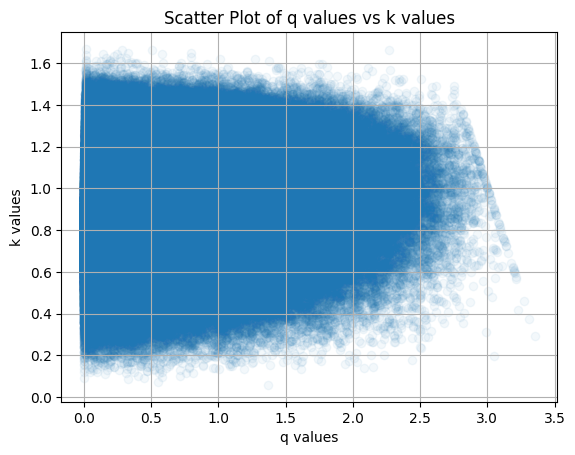

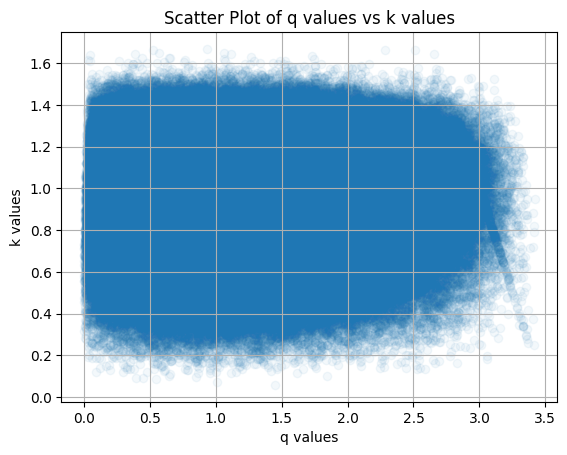

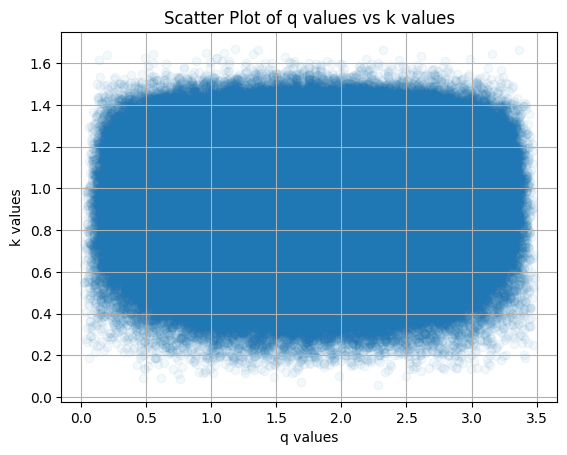

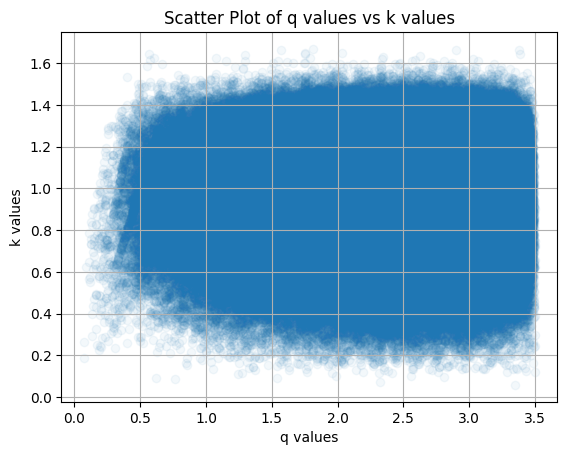

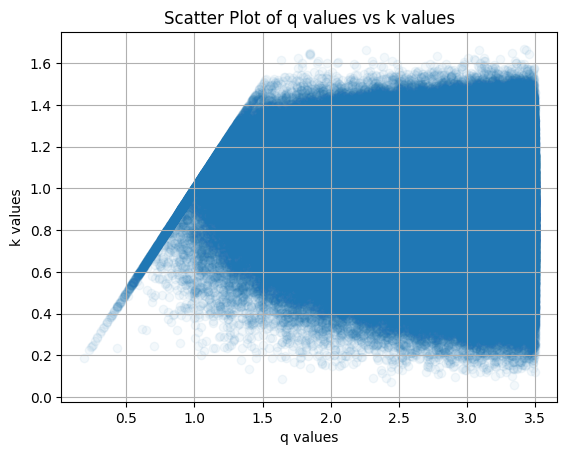

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def sample_ordered_uniform(n_samples, d, q, p, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.uniform(q, p, size=(n_samples, d))
    X.sort(axis=1)  # enforce x1 <= x2 <= ... <= xd
    return X

def local_optimum(q_array, p, n):
    # Vectorized array creation
    dim = -1
    best_q = q_array.copy()

    while True:
        t_array = best_q * np.arange(1, n)[:, np.newaxis]
        t_array_plus = np.mod(t_array, p)
        t_array_minus = p - t_array_plus
        t_array = np.minimum(t_array_plus, t_array_minus)
        row_idx = np.argmin(t_array.max(axis=1))
        dim_idx = np.argmax(t_array[row_idx])
        value = t_array[row_idx, dim_idx]
        print(f"Current best q: {best_q}, k: {value}, changing dimension: {dim_idx}")
        if (dim_idx == dim):
            break
        else:
            dim = dim_idx

        if t_array_plus[row_idx, dim_idx] == t_array_minus[row_idx, dim_idx]: # In principe onnodig
            best_q[dim_idx] = best_q[dim_idx]
        else:
            x = []
            row_mins = t_array.max(axis=1)
            i_range = np.where((t_array[:, dim_idx] == row_mins) & (np.arange(len(t_array)) != row_idx))[0]
            if t_array_plus[row_idx, dim_idx] < t_array_minus[row_idx, dim_idx]:
                for i in i_range:
                    x.append((t_array_minus[i, dim_idx]-value)/(row_idx+i+2))
                best_q[dim_idx] = best_q[dim_idx] + min(x)
            else:
                for i in i_range:
                    x.append((t_array_plus[i, dim_idx]-value)/(row_idx+i+2))
                best_q[dim_idx] = best_q[dim_idx] - min(x)
    return best_q, value
    
# example
p = 7.0
q = 0.0
d = 5
seed = 42  #42 is nice
n_samples = 1000000

q_arrays = sample_ordered_uniform(n_samples, d, q, p/2, seed)
k_s = []
k_max = 0
l_bound = 382

for q_array in q_arrays:
        # Vectorized array creation
        t_array = q_array * np.arange(1, l_bound)[:, np.newaxis]
        t_array = np.mod(t_array, p)
        t_array = np.minimum(t_array, p - t_array)
        # Vectorized min of max
        k_plus = t_array.max(axis=1).min()
        k_s.append(k_plus)
        if k_plus > k_max:
            k_max = k_plus
            q_max = q_array

print(f"Max k found: {max(k_s)} with q_array: {q_max}")
print(f"Average k found: {np.mean(k_s)}")
# local_q, local_k = local_optimum(np.array([0.018,0.128,0.8979,1.997,6.285]), p, l_bound)
local_q, local_k = local_optimum(q_max, p, l_bound)
print(f"Local optimum found: q = {local_q}, k = {local_k}, n/k = {p/local_k}")
for dim in range(d):
    plt.scatter(q_arrays[:, dim], k_s, alpha=0.05, label=f'q[{dim}]')
    plt.xlabel('q values')
    plt.ylabel('k values')
    plt.title('Scatter Plot of q values vs k values')
    plt.grid()
    plt.show()


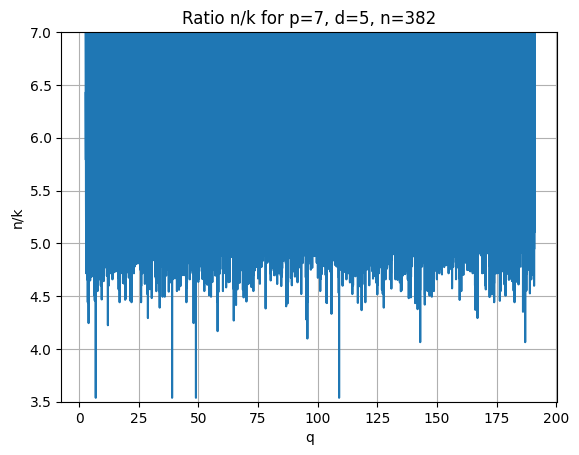

In [21]:
def check_S2(n, d, l_bound):
    k_max = 0
    q_max = []
    for q in range(2, n // 2 + 1):
        q_array = np.array([q**i for i in range(d)])
        # Vectorized: multiply q_array by all t values at once
        t_array = q_array * np.arange(1, l_bound)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array = np.minimum(t_array, n - t_array)
        # Vectorized min of max: find max along each row, then min across rows
        k_plus = t_array.max(axis=1).min()
        if k_plus > k_max:
            k_max = k_plus
            q_max = [q]
        elif k_plus == k_max:
            q_max.append(q)
    return k_max, q_max

def find_solution2(p, d, l_bound):
    print(f"Checking values of n starting from {l_bound} for dimension {d} and p={p}")
    best_result = p
    n = l_bound
    results = []
    x = []
    while best_result > (p/2) and n < 2300:
        max_k, q_max = check_S2(n, d, l_bound)
        if max_k is not None:
            ratio = n/max_k
            x.append(n)
            results.append(ratio)
            print(f"n={n}: max_k={max_k}, n/k={ratio}, q_max={q_max}")
            best_result = min(best_result, ratio)
        n += 1
    print(f"Best ratio {best_result} for n = {n-1} WOEHOEEWW")
    return x, results

def plotting_q(p,d,n):
    q_range = np.linspace(2, n/2, num=189001)
    n_k_ratios = []
    for q in q_range:
        q_array = np.array([q**i for i in range(d)])
        # Vectorized: multiply q_array by all t values at once
        t_array = q_array * np.arange(1, n)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array = np.minimum(t_array, n - t_array)
        # Vectorized min of max: find max along each row, then min across rows
        k_plus = t_array.max(axis=1).min()
        ratio = n/k_plus
        n_k_ratios.append(ratio)
    plt.plot(q_range, n_k_ratios)
    plt.xlabel('q')
    plt.ylabel('n/k')
    plt.ylim(p/2, p)
    plt.title(f'Ratio n/k for p={p}, d={d}, n={n}')
    plt.grid()
    plt.show()
        

import matplotlib.pyplot as plt
# p=7
# d=6
# l_bound=1101
# x, results = find_solution2(p, d, l_bound)
# plt.plot(x, results)
# plt.xlabel('n')
# plt.ylabel('n/k')
# plt.title(f'Ratio n/k for p={p}, d={d} starting from n={l_bound}')
# plt.grid()
# plt.show()
p = 7
d = 5
n = 382
plotting_q(p, d, n)

In [ ]:
from itertools import product
import math
import numpy as np
from tqdm import tqdm
import gurobipy as gp

def generate_shifts(d, shift_size):
    # Implementation for generating shifts
    # Generate all combinations of sets of integers of dimension d and largest integer shift_size-1, first integer can be larger than second etc
    shifts = np.array(list(product(range(shift_size), repeat=d)))
    return shifts

def check_adjacent(point1, point2, p, k):
    for dim in range(len(point1)):
        diff = abs(point1[dim] - point2[dim])
        if diff > (k-1) and diff < (p-(k-1)):
            return False
    return True

def count_adjacencies(point, points, p, k):
    count = 0
    #If for any dimension d , the absolute difference is larger than 1, not adjacent
    for other in points:
        if check_adjacent(point, other, p, k)==True:
            count+=1   
    return count

def return_adjacencies(points, p, k):
    adjacency_counts = []
    for point in points:
        count = count_adjacencies(point, points, p, k)
        adjacency_counts.append(count-1)  # Subtract 1 to not count itself
    return adjacency_counts

def create_independent_points(points, p, k):
    adjacency_counts = return_adjacencies(points, p, k)
    while (max(adjacency_counts) > 0):
        # max_index = adjacency_counts.index(max(adjacency_counts))
        # Set max_index random among the indices that are positive in adjacency_counts
        nonzero_indices = [i for i, count in enumerate(adjacency_counts) if count > 0]
        # max_index = np.random.choice(nonzero_indices)
        max_index = nonzero_indices[0]
        points = np.delete(points, nonzero_indices, axis=0)
        adjacency_counts = return_adjacencies(points, p, k)
    return points

def generate_all_points(n, d):
    total_points = n ** d
    points = np.zeros((total_points, d), dtype=int)
    
    for i in range(total_points):
        for dim in range(d):
            points[i, dim] = (i // (n ** dim)) % n
    return points


def find_available_points(ind_set, other_set, d, p, k):
    available_points = []
    for point in other_set:
        is_available = True
        for ind_point in ind_set:
            # Check adjacency
            if check_adjacent(ind_point, point, p, k):
                is_available = False
                break
        if is_available:
            available_points.append(point)
    
    return np.array(available_points)

def extend_independent_set(ind_set, n, d, k):
    all_points = generate_all_points(n, d)
    other_set = np.array([point for point in all_points if point.tolist() not in ind_set.tolist()])
    available_points = find_available_points(ind_set, other_set, d, n, k)
    print(f"Found {len(available_points)} available points to extend the independent set.")
    while len(available_points) > 0:
        adjacency_counts = return_adjacencies(available_points, n, k)
        min_index = adjacency_counts.index(min(adjacency_counts))
        ind_set = np.vstack([ind_set, available_points[min_index]])
        available_points = np.delete(available_points, min_index, axis=0)
        available_points = find_available_points(ind_set, available_points, d, n, k)

    return ind_set

def maximum_independent_set(points, p, d, k):
    #Find maximum independent set using guroby
    model = gp.Model("max_independent_set")
    x = model.addVars(len(points), vtype=gp.GRB.BINARY, name="x")
    edges = 0
    for i in range(len(points)):
        for j in range(i+1, len(points)):
            if check_adjacent(points[i], points[j], p, k):
                edges += 1
                model.addConstr(x[i] + x[j] <= 1)
    print(f"Number of edges in the conflict graph: {edges}")
    model.setObjective(gp.quicksum(x[i] for i in range(len(points))), gp.GRB.MAXIMIZE)
    model.optimize()
    independent_set = [points[i] for i in range(len(points)) if x[i].X > 0.5]
    return np.array(independent_set)
    
def extend_to_maximum_independent_set(ind_set, p, d, k):
    # print("Extending to maximum independent set using ILP solver...")
    all_points = generate_all_points(p, d)
    # print(f"Generated all points in the space")
    other_set = np.array([point for point in all_points if point.tolist() not in ind_set.tolist()])
    # print(f"Found {len(other_set)} points in the space that are not in the independent set.")
    available_points = find_available_points(ind_set, other_set, d, p, k)
    # print(f"Found {len(available_points)} available points to extend the independent set.")
    extra_set = maximum_independent_set(available_points, p, d, k)
    ind_set = np.vstack([ind_set, extra_set])
    return ind_set

def shift_set(p, large_set):
    n = len(large_set)
    d = len(large_set[0])
    shift_size = math.ceil(2*(n-1)/p)
    #shift_size = (n-1)/p
    print(f"Start generating shifts, shiftsize is {shift_size}")
    # shifts = generate_shifts(d, shift_size)
    # shifts = np.array([[40,123,40,123,40]])
    # print(f"Generated {len(shifts)} shifts.")
    # for shift in shifts:
    i = 0
    while i < 1:
        # q_array = np.ones(5)
        # for j in range(4):
        #     q_array[j+1] = np.random.randint(q_array[j]+1, n-1-(3-j))
        # large_set = (q_array * np.arange(n)[:, np.newaxis])%n
        # shift = np.random.randint(0, shift_size, size=d)
        # # if shift.tolist() == [40,14,40,14,40]:
        # #     print(((shifted_set - np.floor(((large_set + shift) % n) / shift_size))%p).tolist())
        shift = np.array([40,123,123,40,40])
        shifted_set = np.floor(((large_set + shift) % n) / (shift_size/2))
        independent_points = create_independent_points(shifted_set, p, 2)
        print(f"Created independent set of size {len(independent_points)} with q_array {q_array}")
        extended_set = extend_independent_set(independent_points, p, d, 2)
        print(f"Extended to independent set of size {len(extended_set)} using the shift {shift}")
        max_set = extend_to_maximum_independent_set(independent_points, p, d, 2)
        print(f"Extended to maximum independent set of size {len(max_set)} using the shift {shift}")
        i += 1
    return independent_points

p = 7
q = 39
d = 5
n = 382
print(f"Done importing")
q_array = np.array([q**i for i in range(d)])
q_array[1] = -q_array[1]
q_array[2] = -q_array[2]
print(q_array)
# q_array = np.array([1,q,3*q,7*q,11*q])
large_set = (q_array * np.arange(n)[:, np.newaxis])%n
print(f"Generated large set of size {len(large_set)}")
shifted_large_set = shift_set(p, large_set)

Done importing
[      1     -39   -1521   59319 2313441]
Generated large set of size 382
Start generating shifts, shiftsize is 109
Created independent set of size 327 with q_array [      1     -39   -1521   59319 2313441]
Found 70 available points to extend the independent set.
Extended to independent set of size 363 using the shift [40 14 14 40 40]
Number of edges in the conflict graph: 90
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-8265U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 90 rows, 70 columns and 180 nonzeros (Max)
Model fingerprint: 0xe3c4fa75
Model has 70 linear objective coefficients
Variable types: 0 continuous, 70 integer (70 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found he

In [ ]:
d = 5
n = 191
k = 54

coeffs = np.array(
        [[a, 0] for a in range(1,n)] + [[0, b] for b in range(1,n)],
        dtype=np.int64,
    )
q = [7,39]
q_array = np.zeros((2, d), dtype=np.int64)
for j in range(2):
    q_array[j] = np.array([q[j] ** i for i in range(d)], dtype=np.int64)

# Linear combination for each coefficient pair:
# t = a*q_array[0] + b*q_array[1]
large_set = coeffs @ q_array
large_set = np.mod(large_set, n)
print(len(large_set))
print(return_adjacencies(large_set, n, k))
print(len(create_independent_points(large_set, n, k)))

380
[12, 12, 10, 11, 11, 12, 12, 12, 12, 9, 10, 15, 8, 12, 16, 8, 13, 11, 8, 13, 11, 10, 8, 11, 9, 7, 10, 10, 12, 11, 10, 12, 9, 10, 10, 11, 9, 12, 12, 9, 10, 14, 8, 9, 12, 9, 11, 11, 9, 12, 14, 7, 9, 11, 9, 12, 12, 7, 9, 11, 11, 7, 13, 10, 12, 11, 10, 10, 11, 9, 8, 10, 7, 12, 13, 7, 10, 12, 11, 10, 11, 12, 13, 13, 11, 13, 14, 9, 10, 12, 10, 9, 12, 11, 9, 9, 11, 12, 9, 10, 12, 10, 9, 14, 13, 11, 13, 13, 12, 11, 10, 11, 12, 10, 7, 13, 12, 7, 10, 8, 9, 11, 10, 10, 11, 12, 10, 13, 7, 11, 11, 9, 7, 12, 12, 9, 11, 9, 7, 14, 12, 9, 11, 11, 9, 12, 9, 8, 14, 10, 9, 12, 12, 9, 11, 10, 10, 9, 12, 10, 11, 12, 10, 10, 7, 9, 11, 8, 10, 11, 13, 8, 11, 13, 8, 16, 12, 8, 15, 10, 9, 12, 12, 12, 12, 11, 11, 10, 12, 12, 8, 14, 10, 9, 10, 10, 13, 11, 13, 10, 10, 10, 11, 11, 9, 10, 11, 13, 10, 13, 10, 12, 8, 12, 12, 11, 12, 8, 10, 13, 12, 8, 13, 8, 9, 12, 9, 13, 8, 13, 8, 12, 11, 9, 11, 11, 10, 8, 12, 11, 12, 10, 14, 11, 12, 11, 8, 10, 12, 8, 8, 13, 10, 13, 12, 11, 11, 9, 12, 10, 9, 11, 10, 10, 10, 8, 12, 

In [13]:
print((39**4)%382)

49


In [ ]:
import numpy as np


def maximum_independent_set_exact(points, check_adjacency):
    """
    Exact maximum independent set via branch-and-bound with bitsets.

    Parameters
    ----------
    points : array-like of shape (N, d)
        Candidate vertices.
    check_adjacency : callable
        Function check_adjacency(p1, p2) -> bool where True means
        p1 and p2 are adjacent in the conflict graph (so they cannot both
        be in the independent set).

    Returns
    -------
    best_indices : list[int]
        Indices of vertices in a maximum independent set.
    best_points : np.ndarray
        The corresponding points.
    """
    points = np.asarray(points)
    n = len(points)

    if n == 0:
        return [], np.empty((0, 0), dtype=int)

    # Build adjacency bitmasks of the conflict graph.
    adj = [0] * n
    for i in range(n):
        for j in range(i + 1, n):
            if check_adjacency(points[i], points[j]):
                adj[i] |= 1 << j
                adj[j] |= 1 << i

    full_mask = (1 << n) - 1
    best_set = 0
    best_size = 0

    def popcount(x):
        return x.bit_count()

    def choose_vertex(candidates):
        # Branch first on a high-degree vertex for stronger pruning.
        x = candidates
        best_v = -1
        best_deg = -1
        while x:
            lsb = x & -x
            v = lsb.bit_length() - 1
            deg = popcount(adj[v] & candidates)
            if deg > best_deg:
                best_deg = deg
                best_v = v
            x ^= lsb
        return best_v

    def dfs(candidates, current_set, current_size):
        nonlocal best_set, best_size

        # Upper bound: even if we take all candidates, cannot beat current best.
        if current_size + popcount(candidates) <= best_size:
            return

        if candidates == 0:
            if current_size > best_size:
                best_size = current_size
                best_set = current_set
                print(best_size)
            return

        v = choose_vertex(candidates)
        bit_v = 1 << v

        # Include v: remove v and all its neighbors from candidates.
        dfs(candidates & ~adj[v] & ~bit_v, current_set | bit_v, current_size + 1)

        # Exclude v.
        dfs(candidates & ~bit_v, current_set, current_size)

    dfs(full_mask, 0, 0)

    best_indices = [i for i in range(n) if (best_set >> i) & 1]
    best_points = points[best_indices]
    return best_indices, best_points


# Example adapter for your existing signature check_adjacent(point1, point2, p, k)
# Replace p and k with your current values.
def make_check_adjacency(p, k):
    return lambda a, b: check_adjacent(a, b, p, k)


#Example usage:
p = 7
d = 5
k = 2
# shifted_large_set = np.delete(shifted_large_set, 0, axis=0)
while len(shifted_large_set) > 327:
     shifted_large_set = np.delete(shifted_large_set, np.random.randint(0, len(shifted_large_set)), axis=0)
all_points = generate_all_points(p, d)
other_set = np.array([point for point in all_points if point.tolist() not in shifted_large_set.tolist()])
available_points = find_available_points(shifted_large_set, other_set, d, p, k)
print(f"Found {len(available_points)} available points to extend the independent set.")
check_adjacency = make_check_adjacency(p, k)
best_idx, best_independent_set = maximum_independent_set_exact(available_points, check_adjacency)
print("Maximum independent set size:", len(best_idx))

Found 73 available points to extend the independent set.
25
26
27
28
29
30
31
32


KeyboardInterrupt: 

In [ ]:
def maximum_independent_set_heuristic(points, check_adjacency, iterations=100):
    """
    Heuristic maximum independent set using greedy + random restarts.

    Parameters
    ----------
    points : array-like of shape (N, d)
        Candidate vertices.
    check_adjacency : callable
        Function check_adjacency(p1, p2) -> bool where True means
        p1 and p2 are adjacent (cannot both be in the independent set).
    iterations : int
        Number of random restarts to try.

    Returns
    -------
    best_indices : list[int]
        Indices of vertices in the best independent set found.
    best_points : np.ndarray
        The corresponding points.
    """
    points = np.asarray(points)
    n = len(points)

    if n == 0:
        return [], np.empty((0, 0), dtype=int)

    # Build adjacency lists
    adj = [[] for _ in range(n)]
    edge_count = 0
    for i in range(n):
        for j in range(i + 1, n):
            if check_adjacency(points[i], points[j]):
                adj[i].append(j)
                adj[j].append(i)
                edge_count += 1

    print(f"Graph has {n} nodes and {edge_count} edges")

    best_set = []

    for it in range(iterations):
        # Greedy: pick vertex with minimum degree, add it, remove neighbors
        degrees = np.array([len(a) for a in adj])
        available = np.ones(n, dtype=bool)
        current_set = []

        # Shuffle order for randomness on ties
        order = np.arange(n)
        np.random.shuffle(order)

        while available.any():
            # Among available vertices, pick one with minimum current degree
            avail_idx = np.where(available)[0]
            current_degrees = np.array([
                sum(1 for nb in adj[v] if available[nb]) for v in avail_idx
            ])
            # Randomly pick among those tied for minimum degree
            min_deg = current_degrees.min()
            tied = avail_idx[current_degrees == min_deg]
            v = np.random.choice(tied)

            current_set.append(v)
            available[v] = False
            for nb in adj[v]:
                available[nb] = False

        if len(current_set) > len(best_set):
            best_set = current_set
            # print(f"Iteration {it+1}: improved to {len(best_set)}")

    best_indices = sorted(best_set)
    best_points = points[best_indices]
    return best_indices, best_points

In [17]:
def experiment(p, large_set):
    n = len(large_set)
    d = len(large_set[0])
    k = 2
    shift_size = math.ceil(2*(n-1)/p)
    print(f"Start generating shifts, shiftsize is {shift_size}")
    # shifts = generate_shifts(d, shift_size)
    # shifts = np.array([[40,123,40,123,40]])
    # print(f"Generated {len(shifts)} shifts.")
    # for shift in shifts:
    #all_points = generate_all_points(p, d)
    max_l = 0
    while max_l <= 367:
        # q_array = np.ones(5)
        # for j in range(4):
        #     q_array[j+1] = np.random.randint(q_array[j]+1, n-1-(3-j))
        # large_set = (q_array * np.arange(n)[:, np.newaxis])%n
        # shift = np.random.randint(0, shift_size, size=d)
        ##if shift.tolist() == [40,14,40,14,40]:
        # #     print(((shifted_set - np.floor(((large_set + shift) % n) / shift_size))%p).tolist())
        # shift = np.array([40,123,40,123,40])
        shift = np.array([40,-123,-123,40,40])
        shifted_set = np.floor(((large_set + shift) % n) / (shift_size/2))
        independent_points = create_independent_points(shifted_set, p, 2)
        print(f"Created independent set of size {len(independent_points)} with shift {shift}")
        while len(independent_points) > 327:
            independent_points = np.delete(independent_points, np.random.randint(0, len(independent_points)), axis=0)
        #other_set = np.array([point for point in all_points if point.tolist() not in independent_points.tolist()])
        #available_points = find_available_points(independent_points, other_set, d, p, k)
        # print(f"Found {len(available_points)} available points to extend the independent set.")
        # check_adjacency = make_check_adjacency(p, k)
        # best_idx, best_independent_set = maximum_independent_set_heuristic(available_points, check_adjacency)
        # length = len(best_idx)+len(independent_points)
        extended_set = extend_independent_set(independent_points, p, d, 2)
        print(f"Extended to independent set of size {len(extended_set)} using the shift {shift}")
        max_set = extend_to_maximum_independent_set(independent_points, p, d, 2)
        length = len(max_set)
        print(f"Extended to maximum independent set of size {length} using the shift {shift}")
        if length > max_l:
            max_l = length
            maximum_set = max_set

    return max_l, maximum_set

p = 7
q = 39
d = 5
n = 382
#n = 121
print(f"Done importing")
q_array = np.array([q**i for i in range(d)])
#q_array = np.array([1, 3, 11, 33])
large_set = (q_array * np.arange(n)[:, np.newaxis])%n
max_l, maximum_set = experiment(p, large_set)

Done importing
Start generating shifts, shiftsize is 109
Created independent set of size 325 with shift [  40 -123 -123   40   40]
Found 81 available points to extend the independent set.
Extended to independent set of size 365 using the shift [  40 -123 -123   40   40]
Number of edges in the conflict graph: 114
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-8265U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 114 rows, 81 columns and 228 nonzeros (Max)
Model fingerprint: 0xcf00134b
Model has 81 linear objective coefficients
Variable types: 0 continuous, 81 integer (81 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 35.0000000
Presolve removed 114 rows and 81 columns

KeyboardInterrupt: 

In [12]:
def delete_best(large_set, p, k, count):
    adjacency_counts = return_adjacencies(large_set, p, k+1)
    #delete the count points with the lowest adjacency counts
    indices_to_delete = np.argsort(adjacency_counts)[:count]
    new_set = np.delete(large_set, indices_to_delete, axis=0)
    return new_set



def experiment_best_deletions(p, large_set, l_bound):
    n = len(large_set)
    d = len(large_set[0])
    k = 2
    shift_size = math.ceil(8*(n-1)/p)
    print(f"Start generating shifts, shiftsize is {shift_size}")
    max_l = 1086
    i = 0
    while max_l <= l_bound:
        shift_c = np.random.randint(0, math.floor(shift_size/4), size=2)
        shift = np.array([shift_c[0], shift_c[1], shift_c[0], shift_c[1], shift_c[0], shift_c[1]])
        # shift = np.random.randint(0, shift_size, size=d)
        # shift = np.zeros(d, dtype=int)
        shifted_set = np.floor(((large_set + shift) % n) / (shift_size/8))
        independent_points = create_independent_points(shifted_set, p, k)
        print(f"Created independent set of size {len(independent_points)} with shift {shift} and downsizing to {1101-i}")
        # ind_points_at_once = delete_best(independent_points, p, k, i)
        while len(independent_points) > 1101-i:
             independent_points = delete_best(independent_points, p, k, 1)
        max_set = extend_to_maximum_independent_set(independent_points, p, d, k)
        # max_set_at_once = extend_to_maximum_independent_set(ind_points_at_once, p, d, k)
        #max_set = max_set_at_once
        max_set_at_once = max_set
        length = max(len(max_set), len(max_set_at_once))
        print(f"Extended at once to {len(max_set_at_once)} and stepwise to {len(max_set)} using the shift {shift}")
        if length > max_l:
            max_l = length
            if (len(max_set_at_once) > len(max_set)):
                maximum_set = max_set_at_once
            else:
                maximum_set = max_set
        print(f"Current best independent set size: {max_l}")
        # i += 1

    return max_l, maximum_set

p = 7
q = 39
d = 6
n = 1146
print(f"Done importing")
q_array = np.array([q**i for i in range(d)])
large_set = (q_array * np.arange(n)[:, np.newaxis])%n
max_l, maximum_set = experiment_best_deletions(p, large_set, 1101)
print(f"Maximum independent set size found: {max_l}, with points: {maximum_set} WOEHOEW")

Done importing
Start generating shifts, shiftsize is 1309
Created independent set of size 969 with shift [102 217 102 217 102 217] and downsizing to 1101
Number of edges in the conflict graph: 3458
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-8265U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 3458 rows, 560 columns and 6916 nonzeros (Max)
Model fingerprint: 0x846d14c9
Model has 560 linear objective coefficients
Variable types: 0 continuous, 560 integer (560 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 96.0000000
Presolve removed 3451 rows and 553 columns
Presolve time: 0.02s
Presolved: 7 rows, 7 columns, 14 nonzeros
Found heuristic solution: objective 105.0000

KeyboardInterrupt: 

In [35]:
print(np.array([1,7,49,343,109])/382*7)

[0.01832461 0.12827225 0.89790576 6.28534031 1.9973822 ]
